# UPI Fraud Detection

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier
import joblib

%matplotlib inline
np.random.seed(42)

## Creating the dataset

In [2]:
states = ["Maharashtra", "Karnataka", "Delhi", "Tamil Nadu", "West Bengal",
          "Gujarat", "Rajasthan", "Uttar Pradesh", "Andhra Pradesh", "Telangana"]
state_weights = [0.16, 0.11, 0.09, 0.10, 0.08, 0.08, 0.07, 0.13, 0.09, 0.09]

banks = ["SBI", "HDFC", "ICICI", "Axis", "PNB", "Kotak", "IndusInd", "Yes Bank"]
bank_weights = [0.24, 0.18, 0.16, 0.11, 0.09, 0.08, 0.08, 0.06]

merchant_categories = ["Food", "Grocery", "Fuel", "Entertainment", "Shopping",
                        "Healthcare", "Education", "Transport", "Utilities", "P2P Transfer", "Other"]
merchant_weights = [0.14, 0.13, 0.08, 0.07, 0.13, 0.06, 0.04, 0.09, 0.09, 0.13, 0.04]

devices = ["Android", "iOS", "Web"]
device_weights = [0.78, 0.18, 0.04]

networks = ["4G", "5G", "WiFi", "3G"]
network_weights = [0.55, 0.25, 0.18, 0.02]

category_amount_range = {
    "Food": (100, 900), "Grocery": (150, 2500), "Fuel": (200, 3000),
    "Entertainment": (150, 1500), "Shopping": (300, 8000), "Healthcare": (200, 5000),
    "Education": (500, 20000), "Transport": (30, 800), "Utilities": (200, 6000),
    "P2P Transfer": (100, 25000), "Other": (100, 3000),
}

In [3]:
n_senders = 25000
sender_ids = [f"USR{100000+i}" for i in range(n_senders)]
sender_state = np.random.choice(states, size=n_senders, p=state_weights)
sender_bank = np.random.choice(banks, size=n_senders, p=bank_weights)
sender_home_device = np.random.choice(devices, size=n_senders, p=device_weights)

start_date = datetime(2026, 7, 1)
end_date = datetime(2026, 8, 31)
total_seconds = int((end_date - start_date).total_seconds())

N_TRANSACTIONS = 120000
FRAUD_RATE = 0.006
n_fraud_target = int(N_TRANSACTIONS * FRAUD_RATE)
fraud_indices = set(np.random.choice(N_TRANSACTIONS, size=n_fraud_target, replace=False))

rows = []
for i in range(N_TRANSACTIONS):
    sidx = np.random.randint(0, n_senders)
    sender = sender_ids[sidx]
    s_state = sender_state[sidx]
    s_bank = sender_bank[sidx]
    home_device = sender_home_device[sidx]

    merchant_cat = np.random.choice(merchant_categories, p=merchant_weights)
    lo, hi = category_amount_range[merchant_cat]
    amount = round(np.random.uniform(lo, hi), 2)

    ts = start_date + timedelta(seconds=int(np.random.randint(0, total_seconds)))
    hour = ts.hour
    is_weekend = 1 if ts.weekday() >= 5 else 0

    receiver_bank = np.random.choice(banks, p=bank_weights)
    device_type = home_device
    network_type = np.random.choice(networks, p=network_weights)
    is_fraud = 0

    if i in fraud_indices:
        is_fraud = 1
        pattern = np.random.choice(["odd_hour_high_amt", "device_switch", "velocity_burst", "new_bank_combo"])

        if pattern == "odd_hour_high_amt":
            hour = np.random.choice([1, 2, 3, 4, 23])
            amount = round(amount * np.random.uniform(3, 8), 2)
        elif pattern == "device_switch":
            device_type = np.random.choice([d for d in devices if d != home_device])
            amount = round(amount * np.random.uniform(2, 5), 2)
        elif pattern == "velocity_burst":
            amount = round(np.random.uniform(50, 500), 2)
            hour = np.random.choice(range(0, 24))
        elif pattern == "new_bank_combo":
            receiver_bank = np.random.choice([b for b in banks if b != s_bank])
            amount = round(amount * np.random.uniform(4, 10), 2)
            hour = np.random.choice([0, 1, 2, 22, 23])

        if np.random.random() < 0.15:
            amount = round(np.random.uniform(lo, hi), 2)

    rows.append((f"TXN{i+1:07d}", sender, ts, amount, s_state, s_bank, receiver_bank,
                 merchant_cat, device_type, network_type, hour, is_weekend, is_fraud))

df = pd.DataFrame(rows, columns=["transaction_id", "sender_id", "timestamp", "amount", "sender_state",
                                  "sender_bank", "receiver_bank", "merchant_category", "device_type",
                                  "network_type", "hour_of_day", "is_weekend", "fraud_flag"])
df = df.sort_values("timestamp").reset_index(drop=True)

## Exploring the data

In [4]:
df.head()

,transaction_id,sender_id,timestamp,amount,sender_state,sender_bank,receiver_bank,merchant_category,device_type,network_type,hour_of_day,is_weekend,fraud_flag
0,TXN0040690,USR122009,2026-07-01 00:00:48,749.68,Uttar Pradesh,ICICI,IndusInd,Transport,Android,5G,0,0,0
1,TXN0063874,USR105323,2026-07-01 00:02:23,7953.53,Telangana,SBI,ICICI,Shopping,Android,5G,0,0,0
2,TXN0019894,USR114054,2026-07-01 00:02:30,1005.66,Karnataka,SBI,ICICI,Grocery,iOS,4G,0,0,0
3,TXN0018546,USR111278,2026-07-01 00:03:20,19905.33,Uttar Pradesh,SBI,Yes Bank,P2P Transfer,iOS,4G,0,0,0
4,TXN0038875,USR124975,2026-07-01 00:03:59,1188.81,Maharashtra,ICICI,Axis,Grocery,iOS,4G,0,0,0


In [5]:
df.tail()

,transaction_id,sender_id,timestamp,amount,sender_state,sender_bank,receiver_bank,merchant_category,device_type,network_type,hour_of_day,is_weekend,fraud_flag
119995,TXN0001834,USR112907,2026-08-30 23:56:03,19831.16,Uttar Pradesh,SBI,Yes Bank,P2P Transfer,Android,4G,23,1,0
119996,TXN0065662,USR123665,2026-08-30 23:57:17,1431.55,Andhra Pradesh,SBI,HDFC,Grocery,Android,4G,23,1,0
119997,TXN0102293,USR112298,2026-08-30 23:57:33,2857.59,Maharashtra,Axis,Axis,Fuel,iOS,4G,23,1,0
119998,TXN0061558,USR114632,2026-08-30 23:57:55,2097.16,Karnataka,IndusInd,HDFC,Other,Android,WiFi,23,1,0
119999,TXN0066891,USR117531,2026-08-30 23:58:54,2546.38,Tamil Nadu,Yes Bank,SBI,Healthcare,Android,WiFi,23,1,0


In [6]:
df.shape

(120000, 13)

In [7]:
df.columns

Index(['transaction_id', 'sender_id', 'timestamp', 'amount', 'sender_state',
       'sender_bank', 'receiver_bank', 'merchant_category', 'device_type',
       'network_type', 'hour_of_day', 'is_weekend', 'fraud_flag'],
      dtype='str')

In [8]:
df.dtypes

transaction_id                  str
sender_id                       str
timestamp            datetime64[us]
amount                      float64
sender_state                    str
sender_bank                     str
receiver_bank                   str
merchant_category               str
device_type                     str
network_type                    str
hour_of_day                   int64
is_weekend                    int64
fraud_flag                    int64
dtype: object

In [9]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 120000 entries, 0 to 119999
Data columns (total 13 columns):
 #   Column             Non-Null Count   Dtype         
---  ------             --------------   -----         
 0   transaction_id     120000 non-null  str           
 1   sender_id          120000 non-null  str           
 2   timestamp          120000 non-null  datetime64[us]
 3   amount             120000 non-null  float64       
 4   sender_state       120000 non-null  str           
 5   sender_bank        120000 non-null  str           
 6   receiver_bank      120000 non-null  str           
 7   merchant_category  120000 non-null  str           
 8   device_type        120000 non-null  str           
 9   network_type       120000 non-null  str           
 10  hour_of_day        120000 non-null  int64         
 11  is_weekend         120000 non-null  int64         
 12  fraud_flag         120000 non-null  int64         
dtypes: datetime64[us](1), float64(1), int64(3), str(8)
memo

In [10]:
df.isnull().sum()

transaction_id       0
sender_id            0
timestamp            0
amount               0
sender_state         0
sender_bank          0
receiver_bank        0
merchant_category    0
device_type          0
network_type         0
hour_of_day          0
is_weekend           0
fraud_flag           0
dtype: int64

In [11]:
df.describe()

,timestamp,amount,hour_of_day,is_weekend,fraud_flag
count,120000,120000.000000,120000.000000,120000.000000,120000.000000
mean,2026-07-31 10:49:46.072825,3603.762640,11.495058,0.297025,0.006000
min,2026-07-01 00:00:48,30.060000,0.000000,0.000000,0.000000
25%,2026-07-16 02:58:57.750000,622.260000,5.000000,0.000000,0.000000
50%,2026-07-31 10:59:39,1520.880000,12.000000,0.000000,0.000000
75%,2026-08-15 14:48:22.750000,4086.515000,17.000000,1.000000,0.000000
max,2026-08-30 23:58:54,213001.110000,23.000000,1.000000,1.000000
std,NaN,5401.197369,6.925425,0.456950,0.077227


In [12]:
df['fraud_flag'].value_counts()

fraud_flag
0    119280
1       720
Name: count, dtype: int64

In [13]:
df['fraud_flag'].value_counts(normalize=True) * 100

fraud_flag
0    99.4
1     0.6
Name: proportion, dtype: float64

In [14]:
df['merchant_category'].value_counts()

merchant_category
Food             16963
Grocery          15719
P2P Transfer     15633
Shopping         15543
Transport        10701
Utilities        10675
Fuel              9562
Entertainment     8458
Healthcare        7200
Education         4863
Other             4683
Name: count, dtype: int64

In [15]:
df['sender_bank'].value_counts()

sender_bank
SBI         29396
HDFC        21908
ICICI       18837
Axis        13438
PNB         10599
IndusInd     9595
Kotak        9412
Yes Bank     6815
Name: count, dtype: int64

In [16]:
df['device_type'].value_counts()

device_type
Android    93307
iOS        21996
Web         4697
Name: count, dtype: int64

In [17]:
df['amount'].describe()

count    120000.000000
mean       3603.762640
std        5401.197369
min          30.060000
25%         622.260000
50%        1520.880000
75%        4086.515000
max      213001.110000
Name: amount, dtype: float64

## Some plots

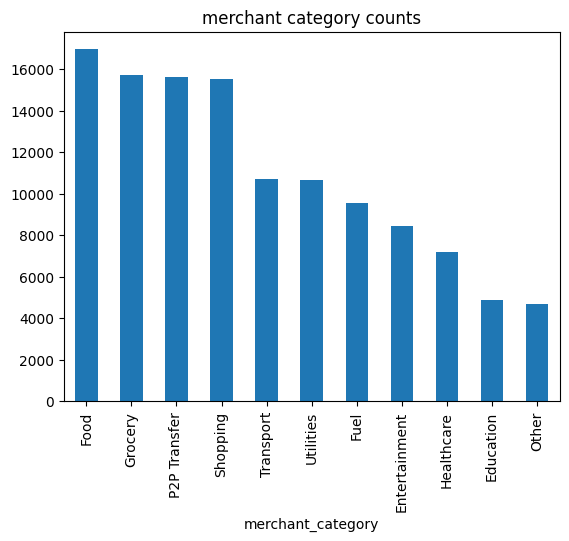

In [18]:
df['merchant_category'].value_counts().plot(kind='bar')
plt.title('merchant category counts')
plt.show()

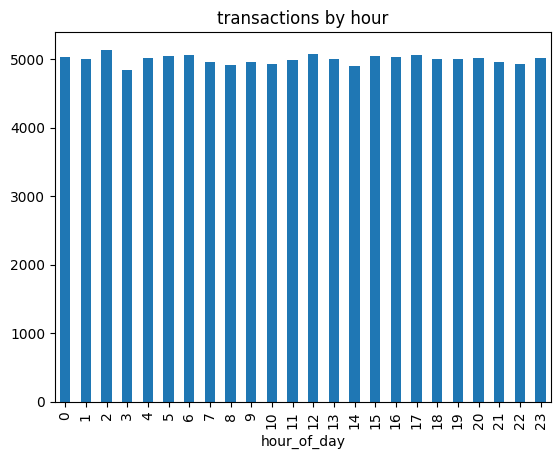

In [19]:
df['hour_of_day'].value_counts().sort_index().plot(kind='bar')
plt.title('transactions by hour')
plt.show()

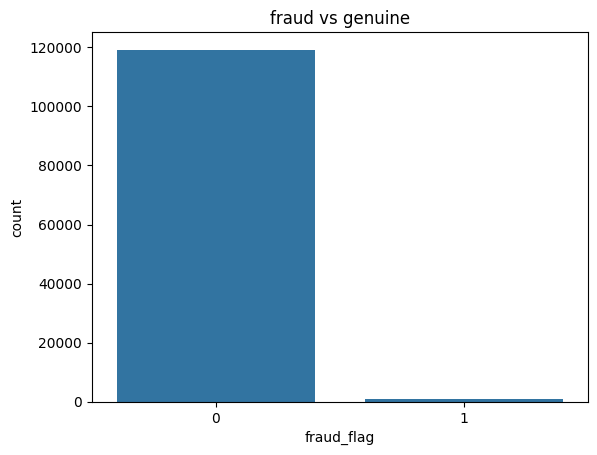

In [20]:
sns.countplot(x='fraud_flag', data=df)
plt.title('fraud vs genuine')
plt.show()

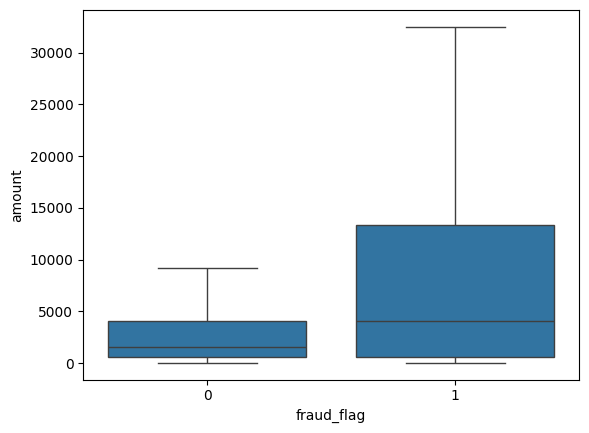

In [21]:
sns.boxplot(x='fraud_flag', y='amount', data=df, showfliers=False)
plt.show()

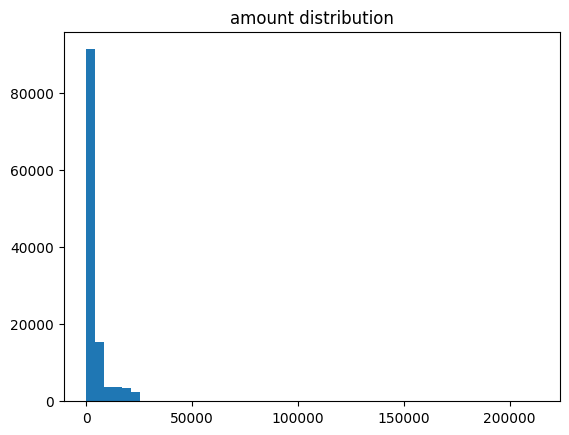

In [22]:
plt.hist(df['amount'], bins=50)
plt.title('amount distribution')
plt.show()

## Adding some new columns

In [23]:
df['timestamp'] = pd.to_datetime(df['timestamp'])
df = df.sort_values(['sender_id', 'timestamp']).reset_index(drop=True)
df['_ts_epoch'] = df['timestamp'].astype('int64') // 10**9

In [24]:
velocity_parts = []
for sender, g in df.groupby('sender_id'):
    times = g['_ts_epoch'].values
    v = np.zeros(len(times), dtype=int)
    start = 0
    for idx in range(len(times)):
        while times[idx] - times[start] > 3600:
            start += 1
        v[idx] = idx - start + 1
    velocity_parts.append(pd.Series(v, index=g.index))
df['txn_velocity_1h'] = pd.concat(velocity_parts).sort_index()

In [25]:
df['sender_running_mean'] = (
    df.groupby('sender_id')['amount'].apply(lambda s: s.shift().expanding().mean())
    .reset_index(level=0, drop=True)
)
df['sender_running_mean'] = df['sender_running_mean'].fillna(df['amount'])
df['amount_deviation_ratio'] = (df['amount'] / df['sender_running_mean'].replace(0, np.nan)).fillna(1.0)

In [26]:
df['is_odd_hour'] = df['hour_of_day'].apply(lambda h: 1 if (h <= 5 or h == 23) else 0)

In [27]:
baseline_device = df.groupby('sender_id').apply(lambda g: g['device_type'].mode().iloc[0])
df['_baseline_device'] = df['sender_id'].map(baseline_device)
df['device_switch_flag'] = (df['device_type'] != df['_baseline_device']).astype(int)

In [28]:
df['cross_bank_flag'] = (df['sender_bank'] != df['receiver_bank']).astype(int)

In [29]:
df = df.drop(columns=['_ts_epoch', '_baseline_device'])
df.head()

,transaction_id,sender_id,timestamp,amount,sender_state,sender_bank,receiver_bank,merchant_category,device_type,network_type,hour_of_day,is_weekend,fraud_flag,txn_velocity_1h,sender_running_mean,amount_deviation_ratio,is_odd_hour,device_switch_flag,cross_bank_flag
0,TXN0075684,USR100000,2026-08-04 06:10:47,1053.85,Tamil Nadu,SBI,IndusInd,Entertainment,iOS,4G,6,0,0,1,1053.850,1.000000,0,0,1
1,TXN0111093,USR100000,2026-08-21 16:10:53,817.87,Tamil Nadu,SBI,SBI,Entertainment,iOS,4G,16,0,0,2,1053.850,0.776078,0,0,0
2,TXN0037424,USR100001,2026-07-03 00:35:14,4848.42,Telangana,SBI,Axis,Utilities,Android,4G,0,0,0,1,4848.420,1.000000,1,0,1
3,TXN0031549,USR100001,2026-08-12 04:34:12,4520.23,Telangana,SBI,PNB,Utilities,Android,4G,4,0,0,2,4848.420,0.932310,1,0,1
4,TXN0031317,USR100001,2026-08-22 12:06:46,292.22,Telangana,SBI,SBI,Transport,Android,5G,12,1,0,2,4684.325,0.062383,0,0,0


In [30]:
df[['txn_velocity_1h', 'amount_deviation_ratio', 'is_odd_hour', 'device_switch_flag', 'cross_bank_flag']].describe()

,txn_velocity_1h,amount_deviation_ratio,is_odd_hour,device_switch_flag,cross_bank_flag
count,120000.000000,120000.000000,120000.000000,120000.000000,120000.000000
mean,3.159042,2.364599,0.292583,0.001450,0.846692
std,1.834646,7.631646,0.454951,0.038051,0.360286
min,1.000000,0.001817,0.000000,0.000000,0.000000
25%,2.000000,0.296523,0.000000,0.000000,1.000000
50%,3.000000,1.000000,0.000000,0.000000,1.000000
75%,4.000000,1.526537,1.000000,0.000000,1.000000
max,14.000000,857.613166,1.000000,1.000000,1.000000


In [31]:
df.groupby('fraud_flag')[['txn_velocity_1h', 'amount_deviation_ratio', 'is_odd_hour', 'device_switch_flag', 'cross_bank_flag']].mean()

,txn_velocity_1h,amount_deviation_ratio,is_odd_hour,device_switch_flag,cross_bank_flag
fraud_flag,,,,,
0,3.158887,2.326308,0.290686,0.000008,0.846470
1,3.184722,8.708153,0.606944,0.240278,0.883333


## Encoding

In [32]:
categorical_cols = ['sender_state', 'sender_bank', 'receiver_bank', 'merchant_category', 'device_type', 'network_type']

le_dict = {}
for col in categorical_cols:
    le = LabelEncoder()
    df[col + '_enc'] = le.fit_transform(df[col])
    le_dict[col] = le

df.head()

,transaction_id,sender_id,timestamp,amount,sender_state,sender_bank,receiver_bank,merchant_category,device_type,network_type,...,amount_deviation_ratio,is_odd_hour,device_switch_flag,cross_bank_flag,sender_state_enc,sender_bank_enc,receiver_bank_enc,merchant_category_enc,device_type_enc,network_type_enc
0,TXN0075684,USR100000,2026-08-04 06:10:47,1053.85,Tamil Nadu,SBI,IndusInd,Entertainment,iOS,4G,...,1.000000,0,0,1,6,6,3,1,2,1
1,TXN0111093,USR100000,2026-08-21 16:10:53,817.87,Tamil Nadu,SBI,SBI,Entertainment,iOS,4G,...,0.776078,0,0,0,6,6,6,1,2,1
2,TXN0037424,USR100001,2026-07-03 00:35:14,4848.42,Telangana,SBI,Axis,Utilities,Android,4G,...,1.000000,1,0,1,7,6,0,10,0,1
3,TXN0031549,USR100001,2026-08-12 04:34:12,4520.23,Telangana,SBI,PNB,Utilities,Android,4G,...,0.932310,1,0,1,7,6,5,10,0,1
4,TXN0031317,USR100001,2026-08-22 12:06:46,292.22,Telangana,SBI,SBI,Transport,Android,5G,...,0.062383,0,0,0,7,6,6,9,0,2


In [33]:
numeric_cols = ['amount', 'hour_of_day', 'is_weekend', 'txn_velocity_1h',
                'amount_deviation_ratio', 'is_odd_hour', 'device_switch_flag', 'cross_bank_flag']
feature_cols = numeric_cols + [c + '_enc' for c in categorical_cols]

X = df[feature_cols]
y = df['fraud_flag']

X.head()

,amount,hour_of_day,is_weekend,txn_velocity_1h,amount_deviation_ratio,is_odd_hour,device_switch_flag,cross_bank_flag,sender_state_enc,sender_bank_enc,receiver_bank_enc,merchant_category_enc,device_type_enc,network_type_enc
0,1053.85,6,0,1,1.000000,0,0,1,6,6,3,1,2,1
1,817.87,16,0,2,0.776078,0,0,0,6,6,6,1,2,1
2,4848.42,0,0,1,1.000000,1,0,1,7,6,0,10,0,1
3,4520.23,4,0,2,0.932310,1,0,1,7,6,5,10,0,1
4,292.22,12,1,2,0.062383,0,0,0,7,6,6,9,0,2


## Train test split

In [34]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print(X_train.shape, X_test.shape)

(96000, 14) (24000, 14)


In [35]:
y_train.value_counts()

fraud_flag
0    95424
1      576
Name: count, dtype: int64

In [36]:
scaler = StandardScaler()
X_train[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])
X_test[numeric_cols] = scaler.transform(X_test[numeric_cols])

## Balancing the data with SMOTE

In [37]:
print('before smote:', y_train.value_counts().to_dict())

sm = SMOTE(random_state=42)
X_train_sm, y_train_sm = sm.fit_resample(X_train, y_train)

print('after smote:', y_train_sm.value_counts().to_dict())

before smote: {0: 95424, 1: 576}


after smote: {0: 95424, 1: 95424}


## Model 1 - Logistic Regression

In [38]:
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train_sm, y_train_sm)
lr_pred = lr.predict(X_test)

lr_acc = accuracy_score(y_test, lr_pred)
lr_prec = precision_score(y_test, lr_pred)
lr_rec = recall_score(y_test, lr_pred)
lr_f1 = f1_score(y_test, lr_pred)

print('accuracy:', lr_acc)
print('precision:', lr_prec)
print('recall:', lr_rec)
print('f1:', lr_f1)
print(confusion_matrix(y_test, lr_pred))
print(classification_report(y_test, lr_pred))

accuracy: 0.8017083333333334
precision: 0.018769551616266946
recall: 0.625
f1: 0.03644462441789836
[[19151  4705]
 [   54    90]]
              precision    recall  f1-score   support

           0       1.00      0.80      0.89     23856
           1       0.02      0.62      0.04       144

    accuracy                           0.80     24000
   macro avg       0.51      0.71      0.46     24000
weighted avg       0.99      0.80      0.88     24000



## Model 2 - Random Forest

In [39]:
rf = RandomForestClassifier(n_estimators=300, random_state=42)
rf.fit(X_train_sm, y_train_sm)
rf_pred = rf.predict(X_test)

rf_acc = accuracy_score(y_test, rf_pred)
rf_prec = precision_score(y_test, rf_pred)
rf_rec = recall_score(y_test, rf_pred)
rf_f1 = f1_score(y_test, rf_pred)

print('accuracy:', rf_acc)
print('precision:', rf_prec)
print('recall:', rf_rec)
print('f1:', rf_f1)
print(confusion_matrix(y_test, rf_pred))
print(classification_report(y_test, rf_pred))

accuracy: 0.9959166666666667
precision: 0.8484848484848485
recall: 0.3888888888888889
f1: 0.5333333333333333
[[23846    10]
 [   88    56]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     23856
           1       0.85      0.39      0.53       144

    accuracy                           1.00     24000
   macro avg       0.92      0.69      0.77     24000
weighted avg       1.00      1.00      1.00     24000



## Model 3 - Decision Tree

In [40]:
dt = DecisionTreeClassifier(max_depth=10, random_state=42)
dt.fit(X_train_sm, y_train_sm)
dt_pred = dt.predict(X_test)

dt_acc = accuracy_score(y_test, dt_pred)
dt_prec = precision_score(y_test, dt_pred)
dt_rec = recall_score(y_test, dt_pred)
dt_f1 = f1_score(y_test, dt_pred)

print('accuracy:', dt_acc)
print('precision:', dt_prec)
print('recall:', dt_rec)
print('f1:', dt_f1)
print(confusion_matrix(y_test, dt_pred))
print(classification_report(y_test, dt_pred))

accuracy: 0.954125
precision: 0.07162041181736795
recall: 0.5555555555555556
f1: 0.126883425852498
[[22819  1037]
 [   64    80]]
              precision    recall  f1-score   support

           0       1.00      0.96      0.98     23856
           1       0.07      0.56      0.13       144

    accuracy                           0.95     24000
   macro avg       0.53      0.76      0.55     24000
weighted avg       0.99      0.95      0.97     24000



## Model 4 - XGBoost

In [41]:
xgb = XGBClassifier(n_estimators=400, max_depth=6, learning_rate=0.08, random_state=42)
xgb.fit(X_train_sm, y_train_sm)
xgb_pred = xgb.predict(X_test)
xgb_proba = xgb.predict_proba(X_test)[:, 1]

xgb_acc = accuracy_score(y_test, xgb_pred)
xgb_prec = precision_score(y_test, xgb_pred)
xgb_rec = recall_score(y_test, xgb_pred)
xgb_f1 = f1_score(y_test, xgb_pred)

print('accuracy:', xgb_acc)
print('precision:', xgb_prec)
print('recall:', xgb_rec)
print('f1:', xgb_f1)
print(confusion_matrix(y_test, xgb_pred))
print(classification_report(y_test, xgb_pred))

accuracy: 0.9964583333333333
precision: 0.8831168831168831
recall: 0.4722222222222222
f1: 0.6153846153846154
[[23847     9]
 [   76    68]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     23856
           1       0.88      0.47      0.62       144

    accuracy                           1.00     24000
   macro avg       0.94      0.74      0.81     24000
weighted avg       1.00      1.00      1.00     24000



## Comparing all the models

In [42]:
comparison = pd.DataFrame({
    'accuracy': [lr_acc, rf_acc, dt_acc, xgb_acc],
    'precision': [lr_prec, rf_prec, dt_prec, xgb_prec],
    'recall': [lr_rec, rf_rec, dt_rec, xgb_rec],
    'f1': [lr_f1, rf_f1, dt_f1, xgb_f1],
}, index=['Logistic Regression', 'Random Forest', 'Decision Tree', 'XGBoost'])

comparison

,accuracy,precision,recall,f1
Logistic Regression,0.801708,0.018770,0.625000,0.036445
Random Forest,0.995917,0.848485,0.388889,0.533333
Decision Tree,0.954125,0.071620,0.555556,0.126883
XGBoost,0.996458,0.883117,0.472222,0.615385


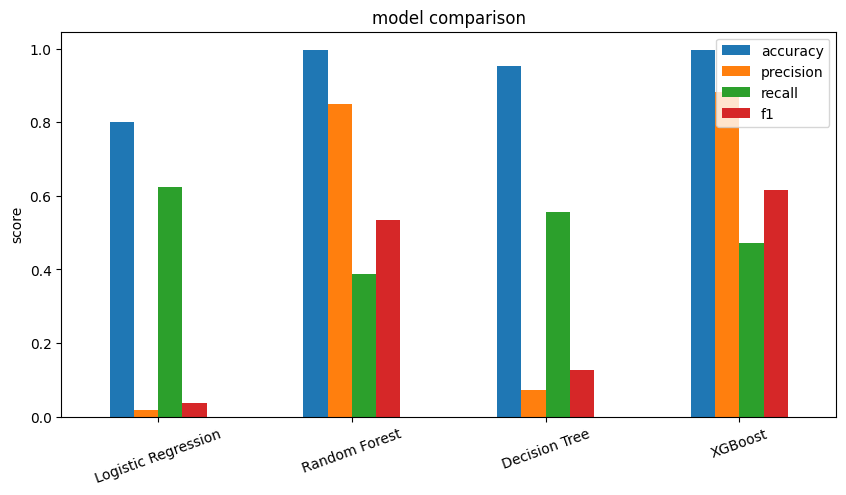

In [43]:
comparison.plot(kind='bar', figsize=(10,5))
plt.title('model comparison')
plt.ylabel('score')
plt.xticks(rotation=20)
plt.show()

Random Forest and XGBoost come out ahead of Logistic Regression and Decision Tree on precision and f1. Decision Tree alone tends to overfit a bit and doesn't generalize as well as Random Forest, which is just a bunch of decision trees averaged together, so that tracks. Going with XGBoost for the rest of the notebook since it edges out Random Forest too.

## Trying a different threshold

In [44]:
for t in [0.3, 0.4, 0.5, 0.6, 0.7]:
    pred_t = (xgb_proba >= t).astype(int)
    print('threshold', t, '-> precision:', round(precision_score(y_test, pred_t), 3),
          'recall:', round(recall_score(y_test, pred_t), 3),
          'f1:', round(f1_score(y_test, pred_t), 3))

threshold 0.3 -> precision: 0.76 recall: 0.507 f1: 0.608
threshold 0.4 -> precision: 0.798 recall: 0.493 f1: 0.609
threshold 0.5 -> precision: 0.883 recall: 0.472 f1: 0.615
threshold 0.6 -> precision: 0.956 recall: 0.451 f1: 0.613
threshold 0.7 -> precision: 0.985 recall: 0.444 f1: 0.612


In [45]:
best_threshold = 0.3
xgb_pred_final = (xgb_proba >= best_threshold).astype(int)

print('accuracy:', accuracy_score(y_test, xgb_pred_final))
print('precision:', precision_score(y_test, xgb_pred_final))
print('recall:', recall_score(y_test, xgb_pred_final))
print('f1:', f1_score(y_test, xgb_pred_final))

accuracy: 0.9960833333333333
precision: 0.7604166666666666
recall: 0.5069444444444444
f1: 0.6083333333333333


## Confusion matrix

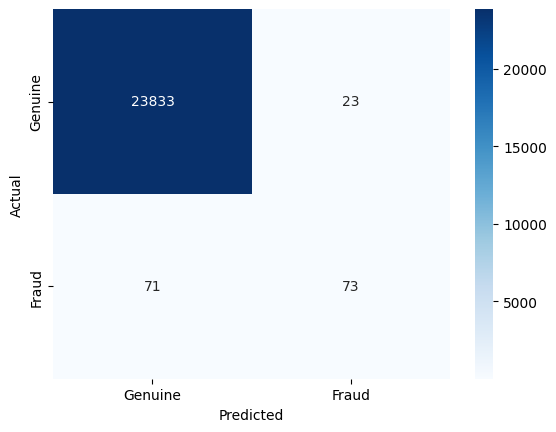

In [46]:
cm = confusion_matrix(y_test, xgb_pred_final)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Genuine','Fraud'], yticklabels=['Genuine','Fraud'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

## Feature importance

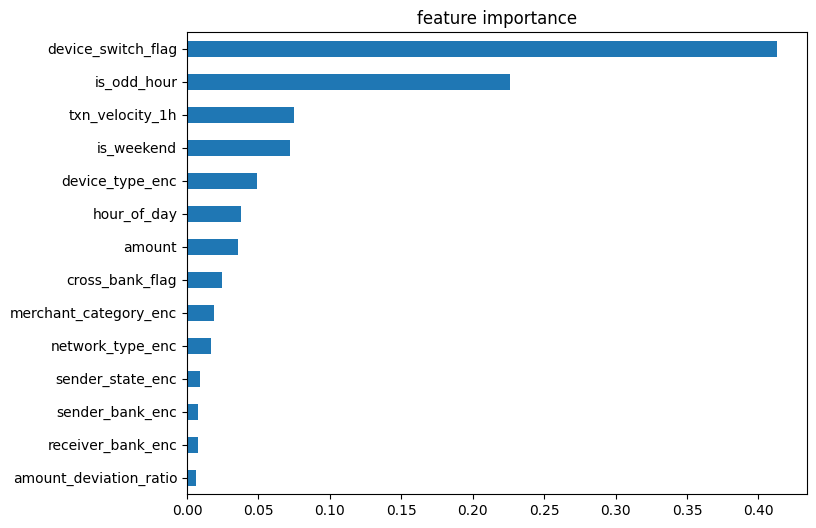

In [47]:
importances = pd.Series(xgb.feature_importances_, index=feature_cols).sort_values(ascending=False)
importances.plot(kind='barh', figsize=(8,6))
plt.gca().invert_yaxis()
plt.title('feature importance')
plt.show()

## Fraud rate by state and category

In [48]:
test_df = df.loc[X_test.index].copy()
test_df['predicted'] = xgb_pred_final

state_risk = test_df.groupby('sender_state')['predicted'].mean().sort_values(ascending=False) * 100
state_risk

sender_state
Karnataka         0.659426
Gujarat           0.508906
Rajasthan         0.472534
Andhra Pradesh    0.461894
Telangana         0.453104
Uttar Pradesh     0.361604
Maharashtra       0.339160
West Bengal       0.310720
Tamil Nadu        0.289975
Delhi             0.184162
Name: predicted, dtype: float64

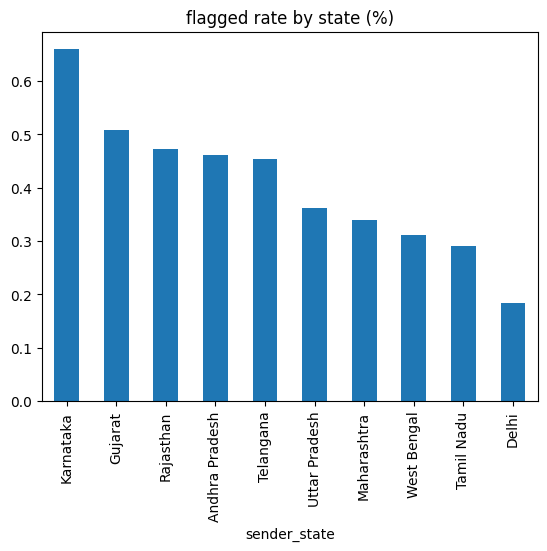

In [49]:
state_risk.plot(kind='bar')
plt.title('flagged rate by state (%)')
plt.show()

In [50]:
category_risk = test_df.groupby('merchant_category')['predicted'].mean().sort_values(ascending=False) * 100
category_risk

merchant_category
P2P Transfer     0.737416
Shopping         0.558843
Entertainment    0.534442
Healthcare       0.485774
Other            0.433839
Fuel             0.421053
Utilities        0.376825
Food             0.296736
Education        0.196078
Grocery          0.188620
Transport        0.090992
Name: predicted, dtype: float64

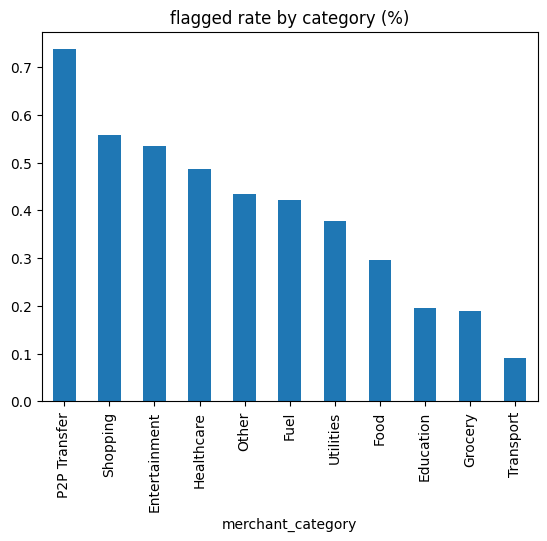

In [51]:
category_risk.plot(kind='bar')
plt.title('flagged rate by category (%)')
plt.show()

## Saving the model

In [52]:
xgb.save_model('xgb_fraud_model.json')
joblib.dump(scaler, 'scaler.pkl')
joblib.dump(le_dict, 'label_encoders.pkl')
print('done')

done
